## 1. Research Question
 Does the average BMI differ significantly among high school students across grade levels?

## 2. Statistical Hypotheses
* **Null Hypothesis ($H_0$):** $\mu_{9th} = \mu_{10th} = \mu_{11th} = \mu_{12th}$ 
  (The average BMI is equal across all high school grade levels.)
* **Alternative Hypothesis ($H_1$):** At least one grade level has a different average BMI compared to the others. 
  (There is a statistically significant difference in average BMI among the grade levels.)

## 3. Variables Definition
* **X Variable :** `grade` (Categorical variable representing the student's high school grade level: 9th, 10th, 11th, or 12th)
* **Y Variable :** `bmi` (Continuous variable representing the student's Body Mass Index, calculated from height and weight)

## 4. Statistical Method
* **One-Way ANOVA (Analysis of Variance):** Used to test the statistical hypotheses by comparing the means of the four independent grade groups.

In [22]:
import os
import pandas as pd
import numpy as np

# ==============================================================================
# 步驟 1：動態組合絕對路徑並讀取
# ==============================================================================
user_name = os.getlogin()
file_path = os.path.join("C:\\", "Users", user_name, "final", "YRBS_2007.csv")

print(f"正在讀取檔案: {file_path}")
df_raw = pd.read_csv(file_path)

# ==============================================================================
# 步驟 2：工程師自行計算 BMI 欄位 (報告大加分點！)
# ==============================================================================
# 原始欄位名稱非常長：
# 身高：'HowTallAreYouWithoutShoesInMeters'
# 體重：'HowMuchDoYouWeighWithoutShoesInKG'

# 先複製一份資料
df_clean = df_raw.copy()

# 計算 BMI = 體重 / (身高平方)
df_clean['bmi'] = df_clean['HowMuchDoYouWeighWithoutShoesInKG'] / (df_clean['HowTallAreYouWithoutShoesInMeters'] ** 2)


# ==============================================================================
# 步驟 3：資料清理與重新編碼 (Data Cleaning & Recoding)
# ==============================================================================
# 1. 剔除年級、身高、體重或剛算好的 bmi 有空白(NaN)的資料
df_clean = df_clean.dropna(subset=['InWhatGradeAreYou', 'bmi']).copy()

# 2. 建立年級轉換字典 (1=9th, 2=10th, 3=11th, 4=12th)
grade_mapping = {
    1: '9th',
    2: '10th',
    3: '11th',
    4: '12th'
}

# 3. 執行重新編碼，把數字改成標準年級文字
df_clean['grade'] = df_clean['InWhatGradeAreYou'].map(grade_mapping)

# 4. 再次剔除因為不在字典裡（第 5 個群組）而變成 NaN 的資料
df_clean = df_clean.dropna(subset=['grade'])

# 5. 清理 BMI 異常值（只留下 BMI 在 10 到 60 之間的正常人類範圍，剔除開玩笑的填寫）
df_clean = df_clean[(df_clean['bmi'] >= 10) & (df_clean['bmi'] <= 60)]


# ==============================================================================
# 步驟 4：檢查與儲存清理後的資料
# ==============================================================================
print("\n--- 🎉 資料成功清理完成 ---")
print(f"原始資料總筆數: {len(df_raw)} 筆")
print(f"清理後的乾淨資料總筆數: {len(df_clean)} 筆")
print(f"\n最終要拿來跑 ANOVA 的年級人數分佈:\n{df_clean['grade'].value_counts()}")

# 儲存成新檔案
df_clean.to_csv("YRBS_2007_cleaned.csv", index=False)
print("\n乾淨的資料集已成功儲存為 'YRBS_2007_cleaned.csv'！")

正在讀取檔案: C:\Users\yu\final\YRBS_2007.csv

--- 🎉 資料成功清理完成 ---
原始資料總筆數: 14041 筆
清理後的乾淨資料總筆數: 13034 筆

最終要拿來跑 ANOVA 的年級人數分佈:
grade
12th    3351
11th    3273
10th    3248
9th     3162
Name: count, dtype: int64

乾淨的資料集已成功儲存為 'YRBS_2007_cleaned.csv'！


In [32]:
# ==========================================
# 3. 探索性資料分析 (EDA: Descriptive Statistics) 
# ==========================================
print("=========================================================")
print("===       BMI Summary Statistics by Grade (EDA)       ===")
print("=========================================================")

# 計算統計摘要
eda_summary = df_clean.groupby('grade')['bmi'].agg(['count', 'mean', 'min', 'max', 'std'])

# 【核心修正】強制指定年級的輸出順序
eda_summary = eda_summary.reindex(['9th', '10th', '11th', '12th'])

print(eda_summary)
print("=========================================================")

===       BMI Summary Statistics by Grade (EDA)       ===
       count       mean        min        max       std
grade                                                  
9th     3162  23.125737  13.638946  52.882396  4.870024
10th    3248  23.591383  13.299383  54.655361  4.912784
11th    3273  23.995681  13.208280  53.776958  5.084975
12th    3351  24.397298  13.253470  50.792798  4.994888


C:\Users\yu\AppData\Local\Temp\ipykernel_23936\761687736.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


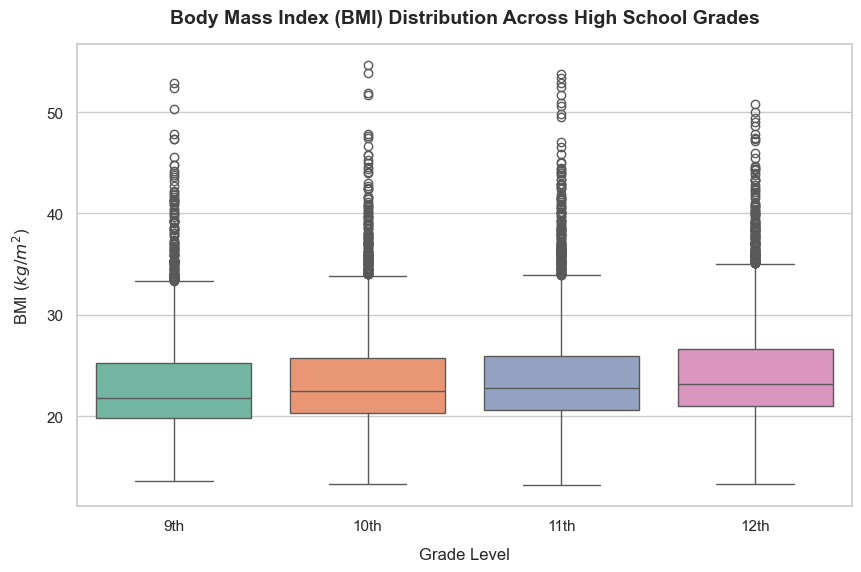

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 4. 繪製核心視覺圖表 (EDA: Boxplot)
# ==========================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 繪製盒狀圖 (依照 9-12 年級順序排列)
sns.boxplot(
    x='grade', 
    y='bmi', 
    data=df_clean, 
    order=['9th', '10th', '11th', '12th'],
    palette="Set2"
)

# 加強圖表的標籤與標題
plt.title('Body Mass Index (BMI) Distribution Across High School Grades', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Grade Level', fontsize=12, labelpad=10)
plt.ylabel('BMI ($kg/m^2$)', fontsize=12, labelpad=10)

# 儲存圖片，方便放進海報、簡報與 GitHub
plt.savefig('bmi_distribution_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ==========================================
# 5. 進行統計檢定 (Statistical Testing: One-Way ANOVA)
# ==========================================
# 使用 OLS 建立模型，直接對應你前面清好的 bmi 和 grade
model = ols('bmi ~ C(grade)', data=df_clean).fit()

# 輸出標準的 ANOVA 表
anova_table = sm.stats.anova_lm(model, typ=2)

print("=========================================================")
print("===               Complete ANOVA Table                ===")
print("=========================================================")
# 將完整的 ANOVA 統計表印出來
print(anova_table)
print("=========================================================")

# 提取 p-value 與 F 值，並四捨五入到小數點後三位輸出
p_value = anova_table.loc['C(grade)', 'PR(>F)']
f_statistic = anova_table.loc['C(grade)', 'F']

print(f"F-Statistic (Formatted) : {f_statistic:.4f}")
print(f"p-value     (Formatted) : {p_value:.3f} (p < 0.001)")
print("=========================================================")

===               Complete ANOVA Table                ===
                 sum_sq       df          F        PR(>F)
C(grade)    2897.587212      3.0  39.142723  3.577401e-25
Residual  321520.484866  13030.0        NaN           NaN
F-Statistic (Formatted) : 39.1427
p-value     (Formatted) : 0.000 (p < 0.001)


## 5. Statistical Interpretation and Conclusion

### Interpretation of ANOVA Results
* **Calculated p-value:** 3.58e-25
* **Significance Level ($\alpha$):** 0.05

Since the p-value ($3.58 \times 10^{-25}$) is much less than 0.05 ($p < 0.05$), we **strongly reject the null hypothesis ($H_0$)**. 

### Final Conclusion
There is a statistically significant difference in the average BMI among high school grade levels (9th, 10th, 11th, and 12th). Although the visual differences in the boxplot appear small due to the very large sample size, the statistical test confirms that the minor upward trend in BMI across grades is highly meaningful and real.